# ETAPA 3 - PRÉ-PROCESSAMENTO E MODELAGEM
## Predição de Doença Cardiovascular com Random Forest

**Dataset:** Cardiovascular Disease Dataset (Kaggle)  
**Objetivo:** Limpar dados, engenharia de features e treinar um modelo Random Forest para classificação.  
**Métrica Principal:** AUC-ROC

---

## 1. Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid", palette="muted")

print("✓ Bibliotecas carregadas com sucesso")

✓ Bibliotecas carregadas com sucesso


## 2. Carregamento do Dataset

In [2]:
df = pd.read_csv('../src/cardio_train.csv', sep=';')
print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

n_original = len(df)

Dataset carregado com sucesso!
Dimensões: 70,000 linhas × 13 colunas


## 3. Pré-processamento dos Dados

In [3]:
print("\n[PRÉ-PROCESSAMENTO]\n")

# 1. Remoção do ID
df = df.drop(columns=['id'])
print("✓ Coluna 'id' removida (não é feature preditiva)")

# 2. Conversão de idade: dias → anos
df['age'] = (df['age'] / 365.25).round(1)
df.rename(columns={'age': 'age_years'}, inplace=True)
print("✓ Idade convertida de dias para anos (age_years = age / 365.25)")

# 3. Engenharia de feature: IMC
df['bmi'] = (df['weight'] / ((df['height'] / 100) ** 2)).round(2)
print("✓ IMC calculado (bmi = weight / (height/100)²)")


[PRÉ-PROCESSAMENTO]

✓ Coluna 'id' removida (não é feature preditiva)
✓ Idade convertida de dias para anos (age_years = age / 365.25)
✓ IMC calculado (bmi = weight / (height/100)²)


In [4]:
# 4. Remoção de registros clinicamente inválidos
mask_invalidos = (
    (df['ap_hi'] <= 0)    | (df['ap_hi'] > 300)   |   # pressão sistólica
    (df['ap_lo'] <= 0)    | (df['ap_lo'] > 200)   |   # pressão diastólica
    (df['ap_hi'] < df['ap_lo'])                    |   # sistólica < diastólica
    (df['height'] < 100)  | (df['height'] > 220)  |   # altura
    (df['weight'] < 30)   | (df['weight'] > 200)       # peso
)

n_invalidos = mask_invalidos.sum()
df_clean = df[~mask_invalidos].copy()

print(f"\nLIMPEZA DE REGISTROS INVÁLIDOS:")
print(f"  Registros originais     : {n_original:,}")
print(f"  Registros removidos     : {n_invalidos:,} ({n_invalidos/n_original*100:.2f}%)")
print(f"  Registros após limpeza  : {len(df_clean):,}")


LIMPEZA DE REGISTROS INVÁLIDOS:
  Registros originais     : 70,000
  Registros removidos     : 1,323 (1.89%)
  Registros após limpeza  : 68,677


In [5]:
# Detalhamento dos critérios de limpeza
print("\nDetalhamento dos critérios de remoção:")
criterios = {
    'ap_hi <= 0 ou > 300 mmHg'           : (df['ap_hi'] <= 0) | (df['ap_hi'] > 300),
    'ap_lo <= 0 ou > 200 mmHg'           : (df['ap_lo'] <= 0) | (df['ap_lo'] > 200),
    'ap_hi < ap_lo (fisicamente imp.)': df['ap_hi'] < df['ap_lo'],
    'height < 100 ou > 220 cm'           : (df['height'] < 100) | (df['height'] > 220),
    'weight < 30 ou > 200 kg'            : (df['weight'] < 30) | (df['weight'] > 200),
}
for criterio, mask in criterios.items():
    print(f"  {criterio:40s}: {mask.sum():,} registros")


Detalhamento dos critérios de remoção:
  ap_hi <= 0 ou > 300 mmHg                : 47 registros
  ap_lo <= 0 ou > 200 mmHg                : 975 registros
  ap_hi < ap_lo (fisicamente imp.)        : 1,234 registros
  height < 100 ou > 220 cm                : 30 registros
  weight < 30 ou > 200 kg                 : 7 registros


In [6]:
# Balanceamento da variável alvo após limpeza
print(f"\nBalanceamento da variável alvo após limpeza:")
vc = df_clean['cardio'].value_counts()
for val, cnt in vc.items():
    label = 'Sem doença' if val == 0 else 'Com doença'
    pct = cnt / len(df_clean) * 100
    print(f"  {label}: {cnt:,} ({pct:.1f}%)")


Balanceamento da variável alvo após limpeza:
  Sem doença: 34,700 (50.5%)
  Com doença: 33,977 (49.5%)


## 4. Separação Features/Alvo e Divisão Treino/Teste

In [7]:
X = df_clean.drop(columns=['cardio'])
y = df_clean['cardio']

# Definição de grupos de colunas
continuous_cols = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']
passthrough_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

# Divisão estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("DIVISÃO DOS DADOS:")
print(f"  Treino : {len(X_train):,} registros ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Teste  : {len(X_test):,} registros ({len(X_test)/len(X)*100:.0f}%)")

DIVISÃO DOS DADOS:
  Treino : 54,941 registros (80%)
  Teste  : 13,736 registros (20%)


In [8]:
# Balanceamento preservado
print(f"\nBalanceamento preservado pela estratificação:")
for split_name, y_split in [('Treino', y_train), ('Teste ', y_test)]:
    sem = (y_split == 0).sum()
    com = (y_split == 1).sum()
    print(f"  {split_name} — sem doença: {sem:,} ({sem/len(y_split)*100:.1f}%)  |  "
          f"com doença: {com:,} ({com/len(y_split)*100:.1f}%)")


Balanceamento preservado pela estratificação:
  Treino — sem doença: 27,760 (50.5%)  |  com doença: 27,181 (49.5%)
  Teste  — sem doença: 6,940 (50.5%)  |  com doença: 6,796 (49.5%)


## 5. Construção do Pipeline e Treinamento

In [9]:
# Preprocessor: normaliza contínuas, mantém categóricas
preprocessor = ColumnTransformer(transformers=[
    ('scaler',      StandardScaler(), continuous_cols),
    ('passthrough', 'passthrough',    passthrough_cols)
], remainder='drop')

# Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Pipeline completo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        model)
])

print("Treinando Random Forest (100 árvores)...")
pipeline.fit(X_train, y_train)
print("✓ Pipeline treinado com sucesso!")

Treinando Random Forest (100 árvores)...
✓ Pipeline treinado com sucesso!


## 6. Avaliação do Modelo

In [10]:
# Predições
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]  # probabilidade da classe positiva

# Cálculo das métricas
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_roc   = roc_auc_score(y_test, y_proba)

print("\n" + "="*50)
print("  MÉTRICAS DE DESEMPENHO — Conjunto de Teste")
print("="*50)
print(f"""
  AUC-ROC  ★ (principal)   :  {auc_roc:.4f}
  Acurácia                 :  {accuracy:.4f}
  Precisão                 :  {precision:.4f}
  Recall (Sensibilidade)   :  {recall:.4f}
  F1-Score                 :  {f1:.4f}
""")
print("="*50)


  MÉTRICAS DE DESEMPENHO — Conjunto de Teste

  AUC-ROC  ★ (principal)   :  0.7700
  Acurácia                 :  0.7080
  Precisão                 :  0.7081
  Recall (Sensibilidade)   :  0.6972
  F1-Score                 :  0.7026



In [11]:
# Relatório completo por classe
print("\nRELATÓRIO COMPLETO POR CLASSE:")
print(classification_report(y_test, y_pred, target_names=['Sem doença (0)', 'Com doença (1)']))


RELATÓRIO COMPLETO POR CLASSE:
                precision    recall  f1-score   support

Sem doença (0)       0.71      0.72      0.71      6940
Com doença (1)       0.71      0.70      0.70      6796

      accuracy                           0.71     13736
     macro avg       0.71      0.71      0.71     13736
  weighted avg       0.71      0.71      0.71     13736



In [12]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("MATRIZ DE CONFUSÃO:")
print(f"  Verdadeiros Negativos (TN): {tn:,}")
print(f"  Falsos Positivos     (FP): {fp:,}")
print(f"  Falsos Negativos     (FN): {fn:,}  ⚠ (não detectar doença)")
print(f"  Verdadeiros Positivos (TP): {tp:,}")

MATRIZ DE CONFUSÃO:
  Verdadeiros Negativos (TN): 4,987
  Falsos Positivos     (FP): 1,953
  Falsos Negativos     (FN): 2,058  ⚠ (não detectar doença)
  Verdadeiros Positivos (TP): 4,738


In [13]:
# Validação cruzada estratificada (5-fold)
print("\nVALIDAÇÃO CRUZADA ESTRATIFICADA (5-fold) — AUC-ROC:")
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Média : {cv_scores.mean():.4f}")
print(f"  Desvio: {cv_scores.std():.4f}")
if cv_scores.std() < 0.01:
    print("  → Baixo desvio padrão: modelo estável entre as partições ✓")


VALIDAÇÃO CRUZADA ESTRATIFICADA (5-fold) — AUC-ROC:
  Fold 1: 0.7702
  Fold 2: 0.7756
  Fold 3: 0.7716
  Fold 4: 0.7732
  Fold 5: 0.7659

  Média : 0.7713
  Desvio: 0.0032
  → Baixo desvio padrão: modelo estável entre as partições ✓


## 7. Visualizações

### Curva ROC

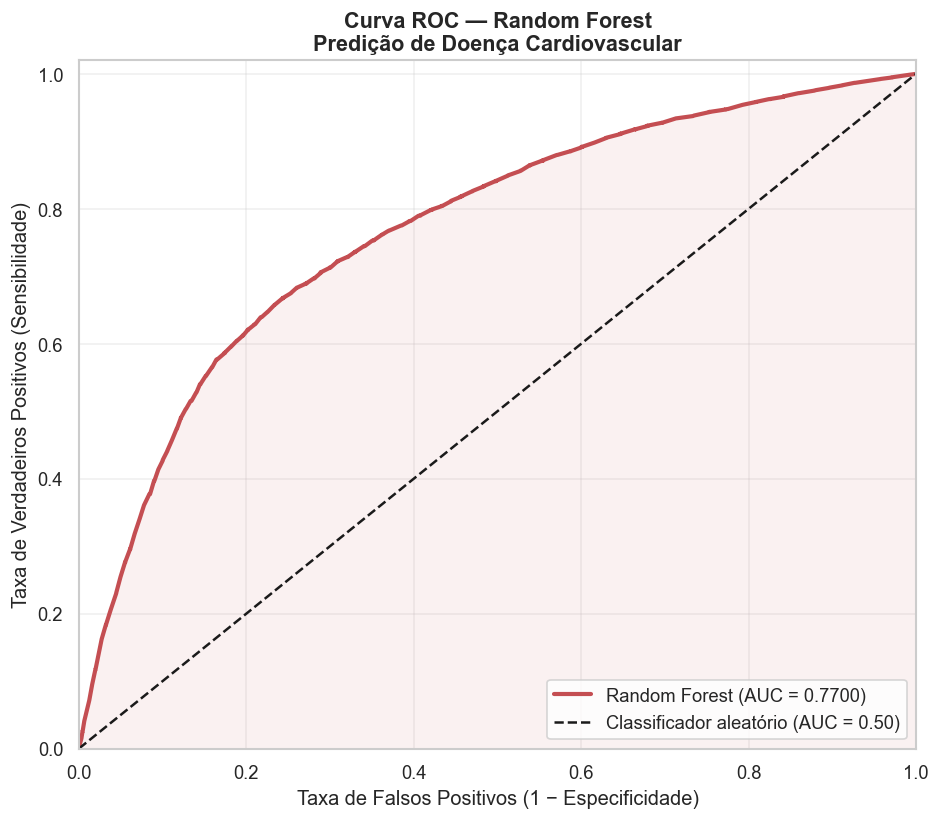

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color='#C44E52', lw=2.5,
        label=f'Random Forest (AUC = {auc_roc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5,
        label='Classificador aleatório (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#C44E52')
ax.set_xlabel('Taxa de Falsos Positivos (1 − Especificidade)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=12)
ax.set_title('Curva ROC — Random Forest\nPredição de Doença Cardiovascular',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
plt.tight_layout()
plt.show()

### Matriz de Confusão

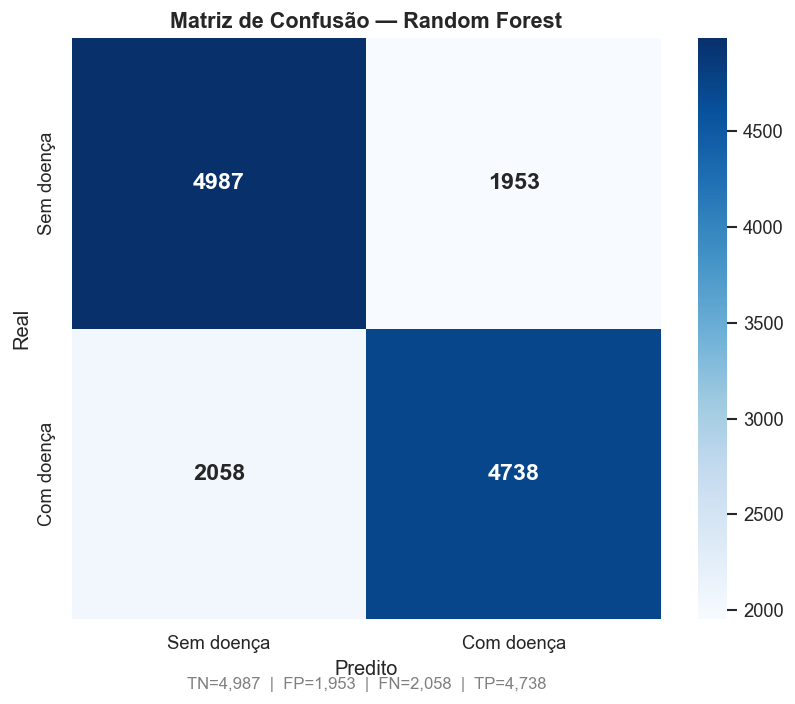

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Sem doença', 'Com doença'],
            yticklabels=['Sem doença', 'Com doença'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_xlabel('Predito', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusão — Random Forest', fontsize=13, fontweight='bold')
ax.text(0.5, -0.12,
        f'TN={tn:,}  |  FP={fp:,}  |  FN={fn:,}  |  TP={tp:,}',
        transform=ax.transAxes, ha='center', fontsize=10, color='gray')
plt.tight_layout()
plt.show()

### Importância das Features

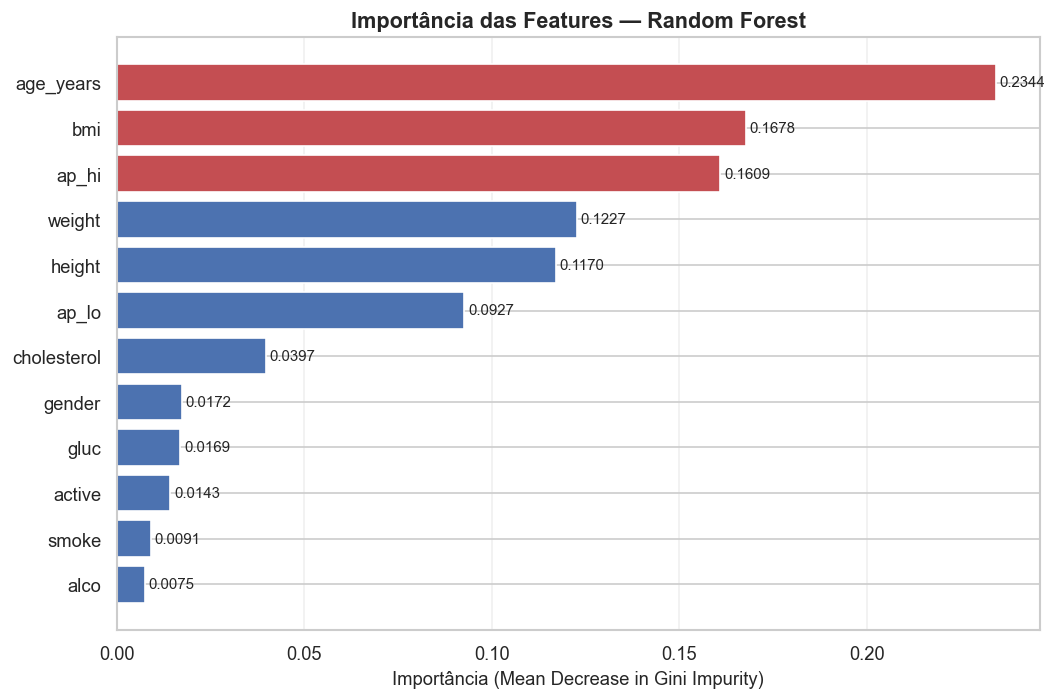


TOP 5 FEATURES MAIS IMPORTANTES:
  height         : 0.1170
  weight         : 0.1227
  ap_hi          : 0.1609
  bmi            : 0.1678
  age_years      : 0.2344


In [16]:
feature_names = continuous_cols + passthrough_cols
importances = pipeline.named_steps['model'].feature_importances_
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True).reset_index(drop=True)

# Top 3 features em vermelho
n = len(feat_df)
colors = ['#C44E52' if i >= n - 3 else '#4C72B0' for i in range(n)]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_df['feature'], feat_df['importance'], color=colors, edgecolor='white')
ax.set_xlabel('Importância (Mean Decrease in Gini Impurity)', fontsize=11)
ax.set_title('Importância das Features — Random Forest', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for i, val in enumerate(feat_df['importance']):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTOP 5 FEATURES MAIS IMPORTANTES:")
for idx, row in feat_df.tail(5).iterrows():
    print(f"  {row['feature']:15s}: {row['importance']:.4f}")

## 8. Resumo Final

In [17]:
print("\n" + "="*65)
print("  RESUMO DA ETAPA 3 — PIPELINE COMPLETO")
print("="*65)
print(f"""
  PRÉ-PROCESSAMENTO
  ├── Remoção do ID
  ├── Conversão de idade: dias → anos
  ├── Feature engineering: IMC = peso / (altura/100)²
  ├── Limpeza de inválidos: {n_invalidos:,} registros ({n_invalidos/n_original*100:.2f}%)
  ├── Normalização (contínuas): StandardScaler
  └── Codificação (categóricas): numéricas já

  DIVISÃO DOS DADOS
  ├── Treino: {len(X_train):,} registros (80%)
  └── Teste: {len(X_test):,} registros (20%)

  MODELO: Random Forest
  ├── n_estimators: 100 árvores
  ├── max_features: sqrt (padrão)
  └── random_state: 42 (reprodutibilidade)

  RESULTADOS — CONJUNTO DE TESTE
  ├── AUC-ROC ★: {auc_roc:.4f}
  ├── Acurácia: {accuracy:.4f}
  ├── Precisão: {precision:.4f}
  ├── Recall: {recall:.4f}
  └── F1-Score: {f1:.4f}

  VALIDAÇÃO CRUZADA (5-fold AUC-ROC)
  └── {cv_scores.mean():.4f} ± {cv_scores.std():.4f}
""")
print("="*65)
print("  Etapa 3 concluída com sucesso! 🎉")
print("="*65)


  RESUMO DA ETAPA 3 — PIPELINE COMPLETO

  PRÉ-PROCESSAMENTO
  ├── Remoção do ID
  ├── Conversão de idade: dias → anos
  ├── Feature engineering: IMC = peso / (altura/100)²
  ├── Limpeza de inválidos: 1,323 registros (1.89%)
  ├── Normalização (contínuas): StandardScaler
  └── Codificação (categóricas): numéricas já

  DIVISÃO DOS DADOS
  ├── Treino: 54,941 registros (80%)
  └── Teste: 13,736 registros (20%)

  MODELO: Random Forest
  ├── n_estimators: 100 árvores
  ├── max_features: sqrt (padrão)
  └── random_state: 42 (reprodutibilidade)

  RESULTADOS — CONJUNTO DE TESTE
  ├── AUC-ROC ★: 0.7700
  ├── Acurácia: 0.7080
  ├── Precisão: 0.7081
  ├── Recall: 0.6972
  └── F1-Score: 0.7026

  VALIDAÇÃO CRUZADA (5-fold AUC-ROC)
  └── 0.7713 ± 0.0032

  Etapa 3 concluída com sucesso! 🎉
